In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
# Cargar datasets (ajusta las rutas)
customer_products = pd.read_csv('../data/datasets_TFM + diccionario/customer_products.csv', sep=',')
df_sales = pd.read_csv('../data/datasets_TFM + diccionario/sales.csv', sep=',')
customer_commercial_activity = pd.read_csv('../data/datasets_TFM + diccionario/customer_commercial_activity.csv', sep=',')
customer_sociodemographics = pd.read_csv('../data/datasets_TFM + diccionario/customer_sociodemographics.csv', sep=',')
sales =pd.read_csv('../data/datasets_TFM + diccionario/sales.csv', sep=',')
products = pd.read_csv('../data/datasets_TFM + diccionario/product_description.csv', sep=',')

In [3]:
# Inicializar el DataFrame final con pk_cid de customer_products
final_df = pd.DataFrame({'pk_cid': customer_products['pk_cid'].unique()})
print(f"DataFrame inicial creado con {len(final_df)} clientes únicos.")

DataFrame inicial creado con 456373 clientes únicos.


In [4]:
# Comprobar IDs faltantes en otros datasets
ids_commercial = set(customer_commercial_activity['pk_cid'].unique())
ids_socio = set(customer_sociodemographics['pk_cid'].unique())
ids_sales = set(sales['cid'].unique())
ids_final = set(final_df['pk_cid'].unique())

missing_commercial = ids_commercial - ids_final
print(f"IDs faltantes en customer_commercial_activity: {len(missing_commercial)}")

missing_socio = ids_socio - ids_final
print(f"IDs faltantes en customer_sociodemographics: {len(missing_socio)}")

missing_sales = ids_sales - ids_final
print(f"IDs faltantes en sales: {len(missing_sales)}")

IDs faltantes en customer_commercial_activity: 0
IDs faltantes en customer_sociodemographics: 0
IDs faltantes en sales: 0


In [5]:
# Podemos imputar con 0s los nulos de customer_products (tras evaluar si cortaba la continuidad de 1s)
customer_products.drop(columns=['Unnamed: 0'], inplace=True)
customer_products['payroll'].fillna(0, inplace=True)
customer_products['pension_plan'].fillna(0, inplace=True)

In [6]:
# Imputamos los nulos de commercial_activity con la moda de su partición
mode_segment = customer_commercial_activity.groupby('pk_partition')['segment'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
mode_channel = customer_commercial_activity.groupby('pk_partition')['entry_channel'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

customer_commercial_activity['segment'] = customer_commercial_activity['segment'].fillna(customer_commercial_activity['pk_partition'].map(mode_segment))
customer_commercial_activity['entry_channel'] = customer_commercial_activity['entry_channel'].fillna(customer_commercial_activity['pk_partition'].map(mode_channel))
customer_commercial_activity.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
# Imputamos los nulos de sociodemographics
# Inferimos el género con lo que se aproxime a la media de salario en su edad
customer_sociodemographics[customer_sociodemographics['pk_cid']==476023] = customer_sociodemographics[customer_sociodemographics['pk_cid']==476023].fillna('H')
customer_sociodemographics[customer_sociodemographics['pk_cid']==216507] = customer_sociodemographics[customer_sociodemographics['pk_cid']==216507].fillna('V')

## MODA POR PARTICIÓN (preprocessing)

# Para inferir el region code:
# 1. Para inferir el 2264 region_codes: los paises que no son 'ES' no tienen region_code (inferimos con -1), y vemos cómo inferimos los de 'ES'...
customer_sociodemographics['region_code'] = customer_sociodemographics['region_code'].fillna(-1)
# 2. Solamente 1 cliente de género 'V' y 45 años que entró en 2018-01: casi el 30% de los 'V' de 45 años que entraron el 2018-01 son de la región 28.0
customer_sociodemographics.loc[customer_sociodemographics['pk_cid']==1234433,'region_code'] = 28.0

# Para inferir el salary:
# Ordenamos por pk_cid y pk_partition
customer_sociodemographics = customer_sociodemographics.sort_values(['pk_cid', 'pk_partition']).reset_index(drop=True)
# Imputamos salary: primero hacia atrás (ffill), luego hacia adelante (bfill)
customer_sociodemographics['salary'] = (
    customer_sociodemographics
        .groupby('pk_cid')['salary']
        .transform(lambda s: s.ffill().bfill()))
# Inferimos el salario por la mediana en cuanto a país, región, género y edad
customer_sociodemographics['salary'] = customer_sociodemographics.groupby(
    ['country_id', 'region_code', 'age']
)['salary'].transform(lambda x: x.fillna(x.median()))
customer_sociodemographics['salary'] = customer_sociodemographics.groupby(
    ['country_id', 'region_code']
)['salary'].transform(lambda x: x.fillna(x.median()))
customer_sociodemographics['salary'] = customer_sociodemographics.groupby(
    ['age']
)['salary'].transform(lambda x: x.fillna(x.median()))
customer_sociodemographics.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
# Empezamos a añadir features de final_df

In [9]:
# Funciones por bloque
# --- Bloque commercial_activity ---
def features_commercial_activity(df):
    # Agrupar entry_channel: valores < 100000 -> 'otro'
    channel_counts = df['entry_channel'].value_counts()
    df['entry_channel_grouped'] = df['entry_channel'].apply(lambda x: x if channel_counts[x] >= 100000 else 'otro')

    # Moda por cliente
    moda_channel = df.groupby('pk_cid')['entry_channel_grouped'].agg(lambda x: x.mode()[0])

    # Segmento más reciente (pk_partition mayor)
    segmento = df.sort_values('pk_partition').groupby('pk_cid')['segment'].last()

    # Meses siendo cliente
    df['entry_date'] = pd.to_datetime(df['entry_date'])
    fecha_referencia = datetime(2019, 5, 1) # Fecha de referencia: primer día de mayo de 2019
    meses_cliente = (fecha_referencia - df.groupby('pk_cid')['entry_date'].min()).dt.days // 30

    # Activo último mes
    ultima_particion = df.sort_values('pk_partition').groupby('pk_cid').tail(1)
    activo_ultimo_mes = ultima_particion.set_index('pk_cid')['active_customer']

    # % meses activo total
    pct_activo_total = df.groupby('pk_cid')['active_customer'].mean()

    # Construir DataFrame reducido
    result = pd.DataFrame({
        'pk_cid': moda_channel.index,
        'entry_channel_mode': moda_channel.values,
        'segment_last': segmento.values,
        'meses_cliente': meses_cliente.values,
        'activo_ultimo_mes': activo_ultimo_mes.values,
        'pct_activo_total': pct_activo_total.values
    })
    return result

# --- Bloque customer_products ---
def features_customer_products(df):
    # Última partición
    ultima = df.sort_values('pk_partition').groupby('pk_cid').tail(1)
    productos_cols = [c for c in df.columns if c not in ['pk_cid','pk_partition']]
    cantidad_actual = ultima[productos_cols].sum(axis=1)
    familias_distintas = ultima[productos_cols].apply(lambda x: (x>0).sum(), axis=1)

    result = pd.DataFrame({
        'pk_cid': ultima['pk_cid'].values,
        'cantidad_productos_actual': cantidad_actual.values,
        'familias_distintas': familias_distintas.values
    })
    return result

# --- Bloque sociodemographics ---
def features_sociodemographics(df):
    ultima = df.sort_values('pk_partition').groupby('pk_cid').tail(1)
    ultima['nacional'] = ultima['country_id'].apply(lambda x: 1 if x=='ES' else 0)
    ultima['rango_salarial'] = pd.qcut(ultima['salary'], q=3, labels=['bajo','medio','alto'])

    result = ultima[['pk_cid','nacional','region_code','gender','age','deceased','salary','rango_salarial']]
    return result

# --- Bloque sales ---
def features_sales(df_sales, df_products):
    df = df_sales.merge(df_products, left_on='product_ID', right_on='pk_product_ID', how='left')

    margen_stats = df.groupby('cid')['net_margin'].agg(['sum','mean','max','min'])
    margen_stats.columns = ['margen_total','margen_medio','margen_max','margen_min']

    df['month_sale'] = pd.to_datetime(df['month_sale'])
    ultima_compra = df.groupby('cid')['month_sale'].max()
    fecha_referencia = datetime(2019, 5, 1) # Fecha de referencia: primer día de mayo de 2019
    tiempo_desde_ultima = (fecha_referencia - ultima_compra).dt.days // 30

    result = pd.DataFrame({
        'pk_cid': margen_stats.index,
        'margen_total': margen_stats['margen_total'].values,
        'margen_medio': margen_stats['margen_medio'].values,
        'margen_max': margen_stats['margen_max'].values,
        'margen_min': margen_stats['margen_min'].values,
        'meses_desde_ultima_compra': tiempo_desde_ultima.values
    })
    return result

In [10]:
feat_comm = features_commercial_activity(customer_commercial_activity)

In [11]:
feat_comm

,pk_cid,entry_channel_mode,segment_last,meses_cliente,activo_ultimo_mes,pct_activo_total
0,15891,KAT,02 - PARTICULARES,10,0.0,0.500000
1,16063,KAT,02 - PARTICULARES,6,0.0,0.714286
2,16203,KAT,01 - TOP,5,0.0,0.833333
3,16502,KHN,02 - PARTICULARES,8,0.0,0.888889
4,17457,KAT,02 - PARTICULARES,20,0.0,1.000000
...,...,...,...,...,...,...
456368,1553685,KHE,03 - UNIVERSITARIO,0,0.0,0.000000
456369,1553686,KHE,03 - UNIVERSITARIO,0,0.0,0.000000
456370,1553687,KHE,03 - UNIVERSITARIO,0,1.0,0.000000
456371,1553688,KHE,03 - UNIVERSITARIO,0,1.0,0.000000


In [12]:
feat_prod = features_customer_products(customer_products)

In [13]:
feat_prod

,pk_cid,cantidad_productos_actual,familias_distintas
0,1298102,0.0,0
1,1297423,0.0,0
2,1299907,0.0,0
3,1299811,0.0,0
4,1299380,0.0,0
...,...,...,...
456368,1489285,0.0,0
456369,1489286,1.0,1
456370,1489287,2.0,2
456371,1489273,1.0,1


In [14]:
feat_demo = features_sociodemographics(customer_sociodemographics)

In [15]:
feat_demo

,pk_cid,nacional,region_code,gender,age,deceased,salary,rango_salarial
4566627,1359556,1,28.0,H,76,N,126718.740,alto
4579787,1360603,1,28.0,H,38,N,107692.800,medio
4526957,1356499,1,28.0,V,28,N,121980.480,alto
4527150,1356512,1,28.0,V,34,N,113044.800,alto
1986122,1157679,1,25.0,H,21,N,64887.525,bajo
...,...,...,...,...,...,...,...,...
4717656,1372518,1,41.0,V,21,N,100726.260,medio
992532,1075574,1,28.0,H,24,N,156830.910,alto
5542363,1468134,1,28.0,V,22,N,144824.160,alto
5542387,1468137,1,18.0,H,20,N,79705.380,medio


In [16]:
feat_sales = features_sales(sales, products)

In [17]:
feat_sales

,pk_cid,margen_total,margen_medio,margen_max,margen_min,meses_desde_ultima_compra
0,15891,66.4,66.40,66.4,66.4,10
1,16203,96.7,96.70,96.7,96.7,4
2,16502,132.9,66.45,68.6,64.3,4
3,17457,56.0,56.00,56.0,56.0,8
4,17970,879.8,439.90,830.3,49.5,2
...,...,...,...,...,...,...
152749,1553456,56.7,56.70,56.7,56.7,0
152750,1553541,66.5,66.50,66.5,66.5,0
152751,1553559,73.0,73.00,73.0,73.0,0
152752,1553565,82.3,82.30,82.3,82.3,0


In [18]:
final_df = final_df.merge(feat_comm, on='pk_cid', how='left')
final_df = final_df.merge(feat_prod, on='pk_cid', how='left')
final_df = final_df.merge(feat_demo, on='pk_cid', how='left')
final_df = final_df.merge(feat_sales, on='pk_cid', how='left')

In [19]:
final_df['meses_desde_ultima_compra'].fillna(-1, inplace=True)
final_df['margen_total'].fillna(0, inplace=True)
final_df['margen_medio'].fillna(0, inplace=True)
final_df['margen_max'].fillna(0, inplace=True)
final_df['margen_min'].fillna(0, inplace=True)

In [20]:
final_df

,pk_cid,entry_channel_mode,segment_last,meses_cliente,activo_ultimo_mes,pct_activo_total,cantidad_productos_actual,familias_distintas,nacional,region_code,gender,age,deceased,salary,rango_salarial,margen_total,margen_medio,margen_max,margen_min,meses_desde_ultima_compra
0,1375586,otro,02 - PARTICULARES,16,1.0,0.529412,2.0,2,1,29.0,H,36,N,87218.10,medio,56.9,56.9,56.9,56.9,12.0
1,1050611,KHE,03 - UNIVERSITARIO,45,0.0,0.000000,1.0,1,1,13.0,V,24,N,35548.74,bajo,0.0,0.0,0.0,0.0,-1.0
2,1050612,KHE,03 - UNIVERSITARIO,45,1.0,0.000000,1.0,1,1,13.0,V,23,N,122179.11,alto,0.0,0.0,0.0,0.0,-1.0
3,1050613,otro,03 - UNIVERSITARIO,45,0.0,0.000000,0.0,0,1,50.0,H,23,N,119775.54,alto,0.0,0.0,0.0,0.0,-1.0
4,1050614,KHE,03 - UNIVERSITARIO,45,0.0,1.000000,1.0,1,1,50.0,V,24,N,93732.03,medio,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456368,1185013,KHE,03 - UNIVERSITARIO,0,0.0,1.000000,1.0,1,1,23.0,V,53,N,60123.69,bajo,60.7,60.7,60.7,60.7,0.0
456369,1168909,KHE,03 - UNIVERSITARIO,33,1.0,1.000000,1.0,1,1,36.0,V,43,N,95623.35,medio,76.0,76.0,76.0,76.0,0.0
456370,1173729,KHE,03 - UNIVERSITARIO,32,1.0,1.000000,1.0,1,1,14.0,H,33,N,62340.33,bajo,59.7,59.7,59.7,59.7,0.0
456371,1164094,KFC,03 - UNIVERSITARIO,0,1.0,1.000000,1.0,1,1,30.0,H,54,N,66790.95,bajo,86.8,86.8,86.8,86.8,0.0


In [21]:
## meses desde la última compra = 10000000, no -1

In [22]:
final_df.columns.tolist()

['pk_cid',
 'entry_channel_mode',
 'segment_last',
 'meses_cliente',
 'activo_ultimo_mes',
 'pct_activo_total',
 'cantidad_productos_actual',
 'familias_distintas',
 'nacional',
 'region_code',
 'gender',
 'age',
 'deceased',
 'salary',
 'rango_salarial',
 'margen_total',
 'margen_medio',
 'margen_max',
 'margen_min',
 'meses_desde_ultima_compra']

----------------------------------------

# CLUSTERING

In [23]:
# Lista de columnas que quieres conservar
cols_to_keep = ['pk_cid', 'meses_desde_ultima_compra', 'pct_activo_total', 'margen_total', 'cantidad_productos_actual', 'meses_cliente']

# Crear un nuevo DataFrame solo con esas columnas o coger todo (ELEGIR)
df_clust = final_df[cols_to_keep] #solo unas columnas
#df_clust = final_df.copy() #todo

# Ponemos el id como índice
df_clust.set_index('pk_cid', inplace=True)

# Verificar resultado
print("Columnas finales:", df_clust.columns.tolist())
print("Shape después de conservar solo x columnas:", df_clust.shape)

Columnas finales: ['meses_desde_ultima_compra', 'pct_activo_total', 'margen_total', 'cantidad_productos_actual', 'meses_cliente']
Shape después de conservar solo x columnas: (456373, 5)


## Empezamos!!

In [24]:
# silence warnings
import warnings
warnings.filterwarnings("ignore")

# time calculation to track some processes
import time

# numeric and matrix operations
import numpy as np

# loading ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# python core library for machine learning and data science
import sklearn
from sklearn import set_config
set_config(transform_output = "pandas")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.cluster import KMeans

In [25]:
def report_df(df, verbose = True):
    '''
    Hace un report simple sobre el DataFrame suministrado.
    '''
    print(df.info(verbose = verbose))
    total_nulos = df.isnull().sum().sum()
    print()
    print(f"Tenemos un total de {total_nulos} nulos")

In [26]:
report_df(df_clust)
df_clust.head()

<class 'pandas.core.frame.DataFrame'>
Index: 456373 entries, 1375586 to 1550586
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   meses_desde_ultima_compra  456373 non-null  float64
 1   pct_activo_total           456373 non-null  float64
 2   margen_total               456373 non-null  float64
 3   cantidad_productos_actual  456373 non-null  float64
 4   meses_cliente              456373 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 20.9 MB
None

Tenemos un total de 0 nulos


,meses_desde_ultima_compra,pct_activo_total,margen_total,cantidad_productos_actual,meses_cliente
pk_cid,,,,,
1375586,12.0,0.529412,56.9,2.0,16
1050611,-1.0,0.000000,0.0,1.0,45
1050612,-1.0,0.000000,0.0,1.0,45
1050613,-1.0,0.000000,0.0,0.0,45
1050614,-1.0,1.000000,0.0,1.0,45


# Detectar valores únicos
valores = df_clust['gender'].unique()
print("Valores únicos:", valores)
# Asignar 0 y 1 automáticamente
df_clust['gender'] = df_clust['gender'].map({valores[0]: 0, valores[1]: 1})

# Detectar valores únicos
valores = df_clust['deceased'].unique()
print("Valores únicos:", valores)
# Asignar 0 y 1 automáticamente
df_clust['deceased'] = df_clust['deceased'].map({valores[0]: 0, valores[1]: 1})

# Detectar valores únicos
valores = df_clust['rango_salarial'].unique()
print("Valores únicos:", valores)
# Asignar 0, 1 y 2 automáticamente
df_clust['rango_salarial'] = df_clust['rango_salarial'].map({valores[0]: 1, valores[1]: 0, valores[2]: 2})
df_clust['rango_salarial'] = df_clust['rango_salarial'].astype('int64')

# como tienen que ser numéricos, me cargo las columnas que no lo sean, para esta prueba
df_clust.drop(columns=['entry_channel_mode', 'segment_last'], inplace=True)
df_clust.info()

## Clusterizamos

In [27]:
pipe = Pipeline(steps = [
    ("Imputer", KNNImputer()),
    ("RobustScaler", RobustScaler(quantile_range = (0, 99.0)))
])

df_transformed = pipe.fit_transform(df_clust)

sse = {}
for k in range(2, 15):

    print(f"Fitting pipe with {k} clusters")

    clustering_model = KMeans(n_clusters = k)
    clustering_model.fit(df_transformed)

    sse[k] = clustering_model.inertia_

Fitting pipe with 2 clusters
Fitting pipe with 3 clusters
Fitting pipe with 4 clusters
Fitting pipe with 5 clusters
Fitting pipe with 6 clusters
Fitting pipe with 7 clusters
Fitting pipe with 8 clusters
Fitting pipe with 9 clusters
Fitting pipe with 10 clusters
Fitting pipe with 11 clusters
Fitting pipe with 12 clusters
Fitting pipe with 13 clusters
Fitting pipe with 14 clusters


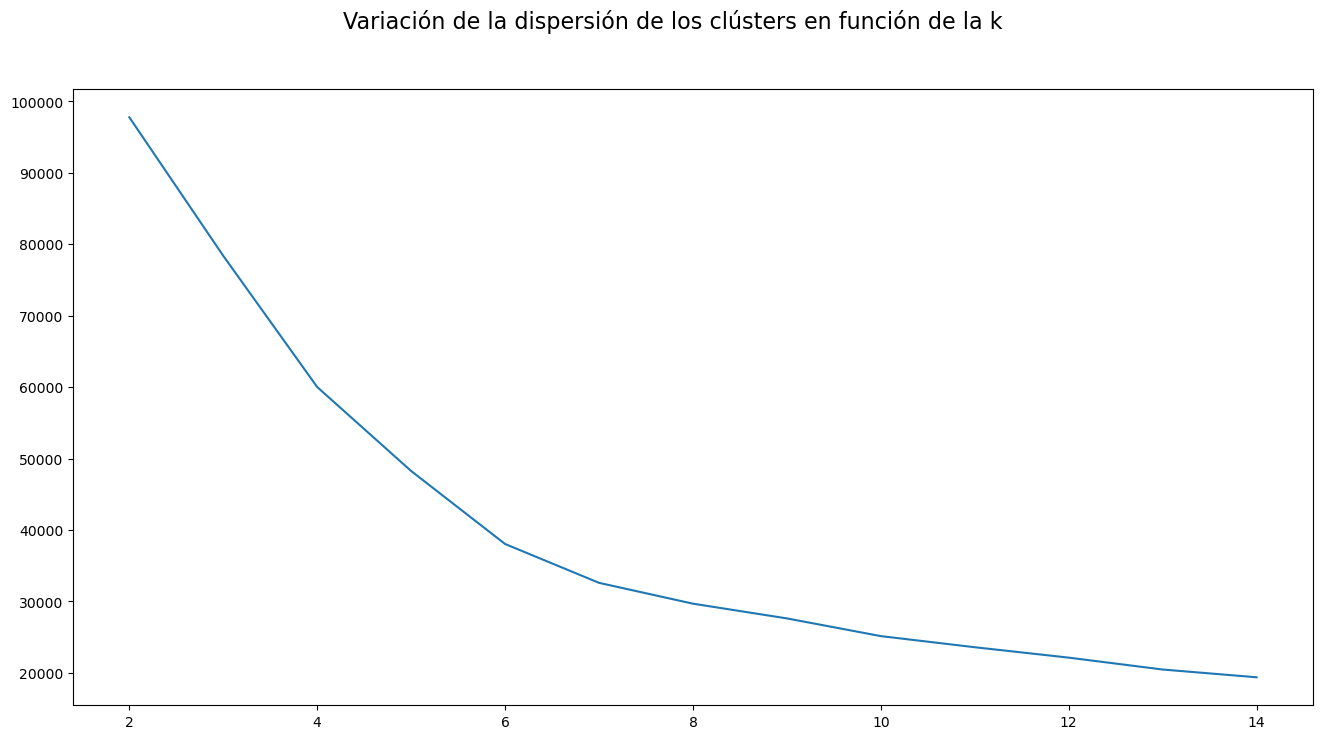

In [28]:
fig = plt.figure(figsize = (16, 8))
ax = fig.add_subplot()

x_values = list(sse.keys())
y_values = list(sse.values())

ax.plot(x_values, y_values, label = "Inertia/dispersión de los clústers")
fig.suptitle("Variación de la dispersión de los clústers en función de la k", fontsize = 16);

In [31]:
pipe2 = Pipeline(steps = [
    ("Imputer", KNNImputer()),
    ("RobustScaler", RobustScaler(quantile_range = (0, 99.0))),
    ("Clustering", KMeans(n_clusters = 6, random_state = 175))
])

In [32]:
pipe2.fit(df_clust)

Pipeline(steps=[('Imputer', KNNImputer()),
                ('RobustScaler', RobustScaler(quantile_range=(0, 99.0))),
                ('Clustering', KMeans(n_clusters=6, random_state=175))])

In [33]:
X_processed = pipe2[:2].transform(df_clust)
X_ = pipe2[:1].transform(df_clust)

In [34]:
labels = pipe2["Clustering"].labels_

In [35]:
# le asignamos al DataFrame procesado el clúster.
# si lo hacemos al df escalado será más díficil de interpretar los resultados porque los números están escalados
#X_processed["cluster"] = labels
X_["cluster"] = labels

In [36]:
X_.shape

(456373, 6)

------------------------------------------

Ficha de los clientes

El último paso, usa vez que tenemos hecha nuestra segmentación completa es crear una ficha resumen de cada grupo con las principales variables de negocio o con aquellas que no se han utilizado en la segmentación para hacer un seguimiento periódico de los grupos o para enviar como documento al resto de los departamentos de la empresa.

In [37]:
ficha_df = pd.DataFrame()

In [38]:
for i, col in enumerate(['meses_desde_ultima_compra', 'pct_activo_total', 'margen_total', 'cantidad_productos_actual', 'meses_cliente']):
    resumen_data = X_[["cluster", col]].groupby("cluster").describe().T[1:]
    ficha_df = pd.concat([ficha_df, resumen_data])

In [39]:
# generamos nuestro multiindex
out_index = [
    'Sales', 
    'Sales', 
    'Sales', 
    'Sales', 
    'Sales'
]

inner_index = ['meses_desde_ultima_compra', 'pct_activo_total', 'margen_total', 'cantidad_productos_actual', 'meses_cliente'
]

estadisticos = ["Media", "Desviación", "Mínimo", "Perc. 25", "Perc. 50", "Perc. 75", "Máximo"]

new_multi_index = []

for oi, ii, in zip(out_index, inner_index):
    for es in estadisticos:
        new_multi_index.append((oi, ii, es))

In [40]:
def generate_multiindex(list_of_tuples, names):
    return pd.MultiIndex.from_tuples(list_of_tuples, names = names)

In [41]:
new_multi_index

[('Sales', 'meses_desde_ultima_compra', 'Media'),
 ('Sales', 'meses_desde_ultima_compra', 'Desviación'),
 ('Sales', 'meses_desde_ultima_compra', 'Mínimo'),
 ('Sales', 'meses_desde_ultima_compra', 'Perc. 25'),
 ('Sales', 'meses_desde_ultima_compra', 'Perc. 50'),
 ('Sales', 'meses_desde_ultima_compra', 'Perc. 75'),
 ('Sales', 'meses_desde_ultima_compra', 'Máximo'),
 ('Sales', 'pct_activo_total', 'Media'),
 ('Sales', 'pct_activo_total', 'Desviación'),
 ('Sales', 'pct_activo_total', 'Mínimo'),
 ('Sales', 'pct_activo_total', 'Perc. 25'),
 ('Sales', 'pct_activo_total', 'Perc. 50'),
 ('Sales', 'pct_activo_total', 'Perc. 75'),
 ('Sales', 'pct_activo_total', 'Máximo'),
 ('Sales', 'margen_total', 'Media'),
 ('Sales', 'margen_total', 'Desviación'),
 ('Sales', 'margen_total', 'Mínimo'),
 ('Sales', 'margen_total', 'Perc. 25'),
 ('Sales', 'margen_total', 'Perc. 50'),
 ('Sales', 'margen_total', 'Perc. 75'),
 ('Sales', 'margen_total', 'Máximo'),
 ('Sales', 'cantidad_productos_actual', 'Media'),
 ('Sal

In [42]:
names = ["Grupo Indicadores", "Indicador", "Estadístico"]
index_ficha = generate_multiindex(new_multi_index, names)
ficha_df.set_index(index_ficha, inplace = True)

In [43]:
ficha_df

cluster                                                             0  \
Grupo Indicadores Indicador                 Estadístico                 
Sales             meses_desde_ultima_compra Media            6.416410   
                                            Desviación       4.610081   
                                            Mínimo           0.000000   
                                            Perc. 25         2.000000   
                                            Perc. 50         6.000000   
                                            Perc. 75        10.000000   
                                            Máximo          15.000000   
                  pct_activo_total          Media            0.931933   
                                            Desviación       0.160361   
                                            Mínimo           0.000000   
                                            Perc. 25         1.000000   
                                            Perc. 50         1.000000   
                                            Perc. 75         1.000000   
                                            Máximo           1.000000   
                  margen_total              Media         6249.937167   
                                            Desviación    2287.857219   
                                            Mínimo          47.100000   
                                            Perc. 25      4657.575000   
                                            Perc. 50      5942.100000   
                                            Perc. 75      7536.225000   
                                            Máximo       18649.900000   
                  cantidad_productos_actual Media            3.046227   
                                            Desviación       1.410846   
                                            Mínimo           0.000000   
                                            Perc. 25         2.000000   
                                            Perc. 50         3.000000   
                                            Perc. 75         4.000000   
                                            Máximo           9.000000   
                  meses_cliente             Media           21.924477   
                                            Desviación      13.666794   
                                            Mínimo           0.000000   
                                            Perc. 25        10.000000   
                                            Perc. 50        19.000000   
                                            Perc. 75        32.000000   
                                            Máximo          52.000000   

cluster                                                            1  \
Grupo Indicadores Indicador                 Estadístico                
Sales             meses_desde_ultima_compra Media          -0.923671   
                                            Desviación      0.423493   
                                            Mínimo         -1.000000   
                                            Perc. 25       -1.000000   
                                            Perc. 50       -1.000000   
                                            Perc. 75       -1.000000   
                                            Máximo          4.000000   
                  pct_activo_total          Media           0.019696   
                                            Desviación      0.087858   
                                            Mínimo          0.000000   
                                            Perc. 25        0.000000   
                                            Perc. 50        0.000000   
                                            Perc. 75        0.000000   
                                            Máximo          0.625000   
                  margen_total              Media           7.137948   
                                            Desviación    131.511432   
  

In [44]:
tamaño_clusters = X_.groupby("cluster").size().to_frame().T
tamaño_clusters.set_index(generate_multiindex([("General", "Clúster", "Tamaño")] , names), inplace = True)

In [45]:
ficha_df = pd.concat([tamaño_clusters, ficha_df])

In [46]:
float_format = '{:.2f}'

In [47]:
ficha_df.style.format(float_format).background_gradient(cmap = 'Blues', axis = 1)

In [48]:
# Evaluamos correlación de variables para cargarnos algunas:

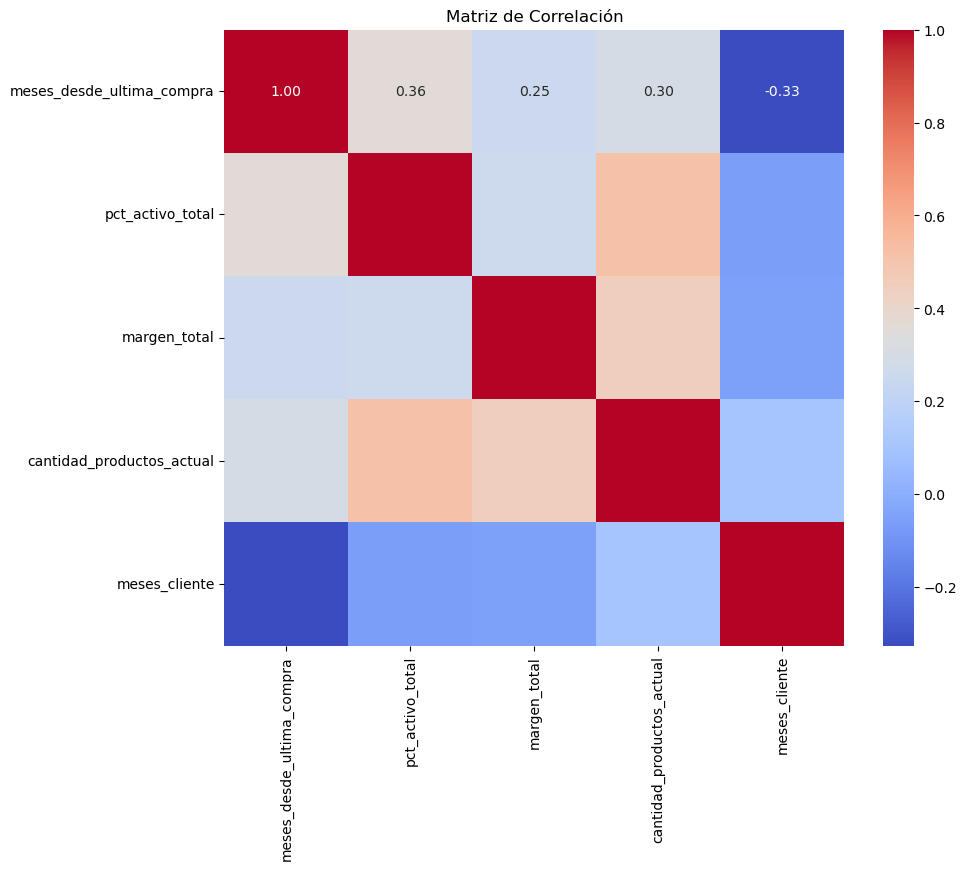

In [49]:
df_corr = df_clust.select_dtypes(include=['number','boolean'])

correlation_matrix = df_corr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [50]:
correlation_matrix.style.format(float_format).background_gradient(cmap = 'Blues', axis = 1)

,meses_desde_ultima_compra,pct_activo_total,margen_total,cantidad_productos_actual,meses_cliente
meses_desde_ultima_compra,1.00,0.36,0.25,0.30,-0.33
pct_activo_total,0.36,1.00,0.26,0.51,-0.06
margen_total,0.25,0.26,1.00,0.45,-0.05
cantidad_productos_actual,0.30,0.51,0.45,1.00,0.10
meses_cliente,-0.33,-0.06,-0.05,0.10,1.00
